# SOTA Time-Series Forecasting: Advanced Recurrent-Attention Hybrid Model
**Dataset:** Individual Household Electric Power Consumption (IHEPC)  
**Location:** Clamart, France (Dec 2006 – Nov 2010)

This notebook implements an advanced State-of-the-Art (SOTA) time-series forecasting model to address the limitations of traditional deep learning architectures for household energy forecasting. We compare the proposed SOTA architecture directly against a multi-step adaptation of the standard **CNN-BiLSTM** baseline.

## The 5 Key SOTA Strategies Implemented:
1. **Multi-Scale Patching:** Parallel patch extraction with different sizes ($P_1 = 8$ for high-frequency details and $P_2 = 24$ for macro trends) aligned at the same temporal endpoints using left-padding.
2. **Reversible Instance Normalization (RevIN):** Normalizes sequence statistics dynamically per-sample to combat seasonal non-stationary distribution shifts.
3. **Cyclical Calendar Embeddings:** Extracts deterministic `hour`, `day_of_week`, and `month` components, converts them using sine/cosine encodings, and projects them to target patch dimensions to act as clean periodic indicators of human routines.
4. **CI + Cross-Variable Attention (iTransformer style):** Channel-independent temporal backbones (GRU/Attention) are applied first, followed by a self-attention layer across the 7 variables to map cross-channel correlations before the forecast.
5. **Smooth L1 Loss (Huber Loss) & Stochastic Weight Averaging (SWA):** Smooth L1 loss prevents load spikes from dominating gradient updates. SWA averages weights over the final epochs to find a flatter local minimum and improve test-set generalization.

---

## 0. Setup and Reproducibility


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Seed for reproducibility
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


Using device: cuda


## 1. Data Loading & Preprocessing
We drop rows with missing values (`?` in raw CSV), combine Date & Time columns, resample to hourly frequency using the mean, and fill any newly created empty bins using forward/backward fill.


In [2]:
def load_and_preprocess_data(filepath):
    print(f"Loading data from {filepath}...")
    df = pd.read_csv(filepath, sep=';', na_values=['?'], dtype={'Date': str, 'Time': str})
    
    # Drop rows with missing values
    initial_len = len(df)
    df = df.dropna()
    print(f"Dropped {initial_len - len(df)} missing rows.")
    
    # Parse Datetime index
    df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], format='%d/%m/%Y %H:%M:%S')
    df = df.drop(columns=['Date', 'Time']).set_index('Datetime')
    
    # Ensure numerical columns
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # Resample to hourly frequency using mean
    df_h = df.resample('h').mean()
    
    # Forward and backward fill resample gaps
    df_h = df_h.ffill().bfill()
    print(f"Processed Hourly Dataset Shape: {df_h.shape}")
    return df_h

# Kaggle Dataset Path
KAGGLE_PATH = '/kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt'
LOCAL_PATH = '../data/household_power_consumption.txt'

if os.path.exists(KAGGLE_PATH):
    df_h = load_and_preprocess_data(KAGGLE_PATH)
elif os.path.exists(LOCAL_PATH):
    df_h = load_and_preprocess_data(LOCAL_PATH)
else:
    # Try current directory or parent directory
    try:
        df_h = load_and_preprocess_data('data/household_power_consumption.txt')
    except Exception:
        print("Data file not found. Please verify the dataset path.")


Loading data from /kaggle/input/datasets/organizations/uciml/electric-power-consumption-data-set/household_power_consumption.txt...
Dropped 25979 missing rows.
Processed Hourly Dataset Shape: (34589, 7)


## 2. Cyclical Calendar Feature Engineering
We extract the `hour_of_day`, `day_of_week`, and `month` components and apply sine/cosine encodings to make them continuous cyclical indicators.


In [3]:
def get_cyclical_calendar_features(df_index):
    hours = df_index.hour.values
    days = df_index.dayofweek.values
    months = df_index.month.values
    
    hour_sin = np.sin(2 * np.pi * hours / 24.0)
    hour_cos = np.cos(2 * np.pi * hours / 24.0)
    
    day_sin = np.sin(2 * np.pi * days / 7.0)
    day_cos = np.cos(2 * np.pi * days / 7.0)
    
    month_sin = np.sin(2 * np.pi * months / 12.0)
    month_cos = np.cos(2 * np.pi * months / 12.0)
    
    calendar_feats = np.stack([hour_sin, hour_cos, day_sin, day_cos, month_sin, month_cos], axis=1)
    return calendar_feats

calendar_features = get_cyclical_calendar_features(df_h.index)
print(f"Calendar features shape: {calendar_features.shape}")


Calendar features shape: (34589, 6)


## 3. Chronological Train-Val-Test Split and Scaling
We perform a zero-leakage split:
* **Train:** Dec 2006 – Dec 2008 (~2 years)
* **Val:** Jan 2009 – Dec 2009 (1 year)
* **Test:** Jan 2010 – Nov 2010 (~11 months)

Targets are scaled using a `StandardScaler` fitted **strictly** on the training partition.


In [4]:
target_cols = ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 
               'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']

# Masks
train_mask = df_h.index < '2009-01-01'
val_mask = (df_h.index >= '2009-01-01') & (df_h.index < '2010-01-01')
test_mask = df_h.index >= '2010-01-01'

df_train = df_h.loc[train_mask]
df_val = df_h.loc[val_mask]
df_test = df_h.loc[test_mask]

print(f"Train hours: {df_train.shape[0]}")
print(f"Val hours: {df_val.shape[0]}")
print(f"Test hours: {df_test.shape[0]}")

# Keep raw targets
train_raw = df_train[target_cols].values
val_raw = df_val[target_cols].values
test_raw = df_test[target_cols].values

# Scale targets (fit strictly on train)
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_raw)
val_scaled = scaler.transform(val_raw)
test_scaled = scaler.transform(test_raw)

# Align calendar features
train_cal = calendar_features[train_mask]
val_cal = calendar_features[val_mask]
test_cal = calendar_features[test_mask]


Train hours: 17911
Val hours: 8760
Test hours: 7918


## 4. PyTorch Dataset & DataLoader
We implement a sliding window dataset returning target lookbacks, calendar lookbacks, and target forecasts.


In [5]:
class TimeSeriesDataset(Dataset):
    def __init__(self, targets_raw, targets_scaled, calendar, lookback, horizon):
        self.targets_raw = targets_raw
        self.targets_scaled = targets_scaled
        self.calendar = calendar
        self.lookback = lookback
        self.horizon = horizon
        
    def __len__(self):
        return len(self.targets_raw) - self.lookback - self.horizon + 1
        
    def __getitem__(self, idx):
        x_raw = self.targets_raw[idx : idx + self.lookback]
        x_scaled = self.targets_scaled[idx : idx + self.lookback]
        x_calendar = self.calendar[idx : idx + self.lookback]
        y_raw = self.targets_raw[idx + self.lookback : idx + self.lookback + self.horizon]
        y_scaled = self.targets_scaled[idx + self.lookback : idx + self.lookback + self.horizon]
        
        return (torch.FloatTensor(x_raw), 
                torch.FloatTensor(x_scaled), 
                torch.FloatTensor(x_calendar), 
                torch.FloatTensor(y_raw),
                torch.FloatTensor(y_scaled))

LOOKBACK = 96
HORIZON = 24
BATCH_SIZE = 128

train_dataset = TimeSeriesDataset(train_raw, train_scaled, train_cal, LOOKBACK, HORIZON)
val_dataset = TimeSeriesDataset(val_raw, val_scaled, val_cal, LOOKBACK, HORIZON)
test_dataset = TimeSeriesDataset(test_raw, test_scaled, test_cal, LOOKBACK, HORIZON)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

x_raw, x_scaled, x_c, y_raw, y_scaled = next(iter(train_loader))
print(f"Batch raw targets lookback shape: {x_raw.shape} -> [Batch, Lookback, 7]")
print(f"Batch scaled targets lookback shape: {x_scaled.shape} -> [Batch, Lookback, 7]")
print(f"Batch calendar lookback shape: {x_c.shape} -> [Batch, Lookback, 6]")
print(f"Batch targets forecast shape: {y_raw.shape} -> [Batch, Horizon, 7]")


Batch raw targets lookback shape: torch.Size([128, 96, 7]) -> [Batch, Lookback, 7]
Batch scaled targets lookback shape: torch.Size([128, 96, 7]) -> [Batch, Lookback, 7]
Batch calendar lookback shape: torch.Size([128, 96, 6]) -> [Batch, Lookback, 6]
Batch targets forecast shape: torch.Size([128, 24, 7]) -> [Batch, Horizon, 7]


## 5. Reversible Instance Normalization (RevIN) & SOTA Model
We define `RevIN` and the main `SOTAForecastingModel`.


In [6]:
class RevIN(nn.Module):
    def __init__(self, num_features, eps=1e-5, affine=True):
        super().__init__()
        self.eps = eps
        self.affine = affine
        if self.affine:
            self.affine_weight = nn.Parameter(torch.ones(num_features))
            self.affine_bias = nn.Parameter(torch.zeros(num_features))
            
    def forward(self, x, mode='norm', mean=None, stdev=None):
        if mode == 'norm':
            self.mean = torch.mean(x, dim=1, keepdim=True).detach()
            self.stdev = torch.sqrt(torch.var(x, dim=1, keepdim=True, unbiased=False) + self.eps).detach()
            x = (x - self.mean) / self.stdev
            if self.affine:
                x = x * self.affine_weight + self.affine_bias
            return x, self.mean, self.stdev
        elif mode == 'denorm':
            if self.affine:
                x = (x - self.affine_bias) / (self.affine_weight + self.eps)
            x = x * stdev + mean
            return x

class SOTAForecastingModel(nn.Module):
    def __init__(self, num_targets, patch_len_1=8, patch_len_2=24, stride=8, 
                 lookback=96, d_model=64, d_channel=256, forecast_horizon=24):
        super().__init__()
        self.num_targets = num_targets
        self.patch_len_1 = patch_len_1
        self.patch_len_2 = patch_len_2
        self.stride = stride
        self.lookback = lookback
        self.d_model = d_model
        self.d_channel = d_channel
        self.forecast_horizon = forecast_horizon
        
        # Calculate patch count (based on scale 1)
        self.num_patches = (lookback - patch_len_1) // stride + 1
        
        self.revin = RevIN(num_features=num_targets)
        
        # Multi-scale patch embedding
        self.embed_1 = nn.Linear(patch_len_1, d_model)
        self.embed_2 = nn.Linear(patch_len_2, d_model)
        
        # Calendar embedding
        self.calendar_embed = nn.Linear(6, 2 * d_model)
        
        # Temporal Backbone
        self.gru = nn.GRU(d_model * 2, d_model, batch_first=True, bidirectional=True)
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model * 2, nhead=4, dim_feedforward=d_model * 4, batch_first=True, dropout=0.2),
            num_layers=2
        )
        
        # Cross-Variable Attention (iTransformer style)
        self.flat_dim = self.num_patches * (d_model * 2)
        self.channel_proj = nn.Linear(self.flat_dim, d_channel)
        
        self.cross_var_attn = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_channel, nhead=8, dim_feedforward=d_channel * 2, batch_first=True, dropout=0.2),
            num_layers=1
        )
        
        # Prediction Head
        self.predict_head = nn.Linear(d_channel, forecast_horizon)
        
    def forward(self, x_targets, x_calendar):
        batch_size = x_targets.shape[0]
        
        # 1. Normalize targets
        x_norm, mean, stdev = self.revin(x_targets, mode='norm')
        
        # 2. Reshape for Channel Independence: [Batch * Num_Targets, Lookback, 1]
        x_ci = x_norm.transpose(1, 2).reshape(batch_size * self.num_targets, -1, 1)
        
        # 3. Patching Targets - Scale 1 (P_1 = 8)
        patches_1 = x_ci.unfold(dimension=1, size=self.patch_len_1, step=self.stride).squeeze(2)
        
        # 4. Patching Targets - Scale 2 (P_2 = 24)
        pad_len = self.patch_len_2 - self.patch_len_1
        # Left-pad sequence to keep endpoint alignment
        x_ci_padded = torch.cat([x_ci[:, :1, :].repeat(1, pad_len, 1), x_ci], dim=1)
        patches_2 = x_ci_padded.unfold(dimension=1, size=self.patch_len_2, step=self.stride).squeeze(2)
        
        # 5. Project & Concatenate embeddings: [Batch * Num_Targets, Num_Patches, 2 * d_model]
        embed_1 = self.embed_1(patches_1)
        embed_2 = self.embed_2(patches_2)
        feat_in = torch.cat([embed_1, embed_2], dim=-1)
        
        # 6. Extract & project Calendar features at patch endpoints
        patch_indices = [i * self.stride + self.patch_len_1 - 1 for i in range(self.num_patches)]
        cal_patched = x_calendar[:, patch_indices, :]
        cal_feat = self.calendar_embed(cal_patched)
        
        # Repeat calendar features for channel independence
        cal_feat = cal_feat.repeat_interleave(self.num_targets, dim=0)
        
        # Add calendar embeddings directly to patch embeddings
        feat_in = feat_in + cal_feat
        
        # 7. Temporal sequential layers
        gru_out, _ = self.gru(feat_in)
        tf_out = self.transformer(gru_out)
        
        # 8. Prepare for Cross-Variable Attention
        tf_flat = tf_out.reshape(batch_size * self.num_targets, -1)
        channel_feats = tf_flat.reshape(batch_size, self.num_targets, -1)
        channel_feats = self.channel_proj(channel_feats)
        
        # Self-Attention across channels
        cross_out = self.cross_var_attn(channel_feats)
        
        # 9. Project to Forecast Horizon
        preds = self.predict_head(cross_out)
        preds = preds.transpose(1, 2) # [Batch, Horizon, Num_Targets]
        
        # 10. Denormalize via RevIN
        pred_final = self.revin(preds, mode='denorm', mean=mean, stdev=stdev)
        return pred_final


## 6. Baseline CNN-BiLSTM Model
We implement the standard CNN-BiLSTM model, adapted for 24-step forecasting of all 7 target variables.


In [7]:
class CNN_BiLSTM(nn.Module):
    def __init__(self, num_targets, forecast_horizon, cnn_filters=64, lstm_hidden=64):
        super(CNN_BiLSTM, self).__init__()
        self.num_targets = num_targets
        self.forecast_horizon = forecast_horizon
        
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=num_targets, out_channels=cnn_filters, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters, kernel_size=2, padding=1),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        self.lstm = nn.LSTM(
            input_size=cnn_filters, 
            hidden_size=lstm_hidden, 
            num_layers=2, 
            batch_first=True, 
            bidirectional=True
        )
        
        self.fc = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, forecast_horizon * num_targets)
        )
        
    def forward(self, x_targets, x_calendar=None):
        # x_targets is [batch, seq_len, num_targets]
        x = x_targets.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        out, _ = self.lstm(x)
        last_out = out[:, -1, :]
        pred = self.fc(last_out)
        return pred.view(-1, self.forecast_horizon, self.num_targets)


## 7. Custom SWA BN Updater & Training Loop
We define a training loop that supports standard Adam optimizer updates, `SmoothL1Loss` (for SOTA) or `MSELoss` (for baseline), and standard PyTorch Stochastic Weight Averaging (SWA) during the final epochs.


In [8]:
from torch.optim.swa_utils import AveragedModel, SWALR

def update_swa_bn(loader, swa_model, device):
    """Custom SWA batchnorm/forward updater supporting multiple inputs"""
    swa_model.train()
    with torch.no_grad():
        for x_raw, x_scaled, x_cal, _, _ in loader:
            x_raw = x_raw.to(device)
            x_cal = x_cal.to(device)
            swa_model(x_raw, x_cal)

def train_model(model, train_loader, val_loader, epochs=15, lr=0.001, 
                criterion_type='mse', use_swa=False, device='cpu'):
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    if criterion_type == 'huber':
        criterion = nn.SmoothL1Loss(beta=1.0)
    else:
        criterion = nn.MSELoss()
        
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
    
    best_val_loss = float('inf')
    best_weights = None
    patience_counter = 0
    patience = 3
    
    history = {'train_loss': [], 'val_loss': []}
    
    # SWA setup
    if use_swa:
        swa_model = AveragedModel(model)
        # SWA starts at 80% of epochs (e.g. epoch 12 for 15 epochs)
        swa_start_epoch = int(epochs * 0.8)
        swa_scheduler = SWALR(optimizer, swa_lr=0.0001)
        print(f"SWA enabled: starting at epoch {swa_start_epoch + 1}")
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        
        for x_raw, x_scaled, x_cal, y_raw, y_scaled in train_loader:
            x_raw, x_scaled, x_cal = x_raw.to(device), x_scaled.to(device), x_cal.to(device)
            y_raw, y_scaled = y_raw.to(device), y_scaled.to(device)
            optimizer.zero_grad()
            
            if isinstance(model, SOTAForecastingModel):
                preds = model(x_raw, x_cal)
                loss = criterion(preds, y_raw)
            else:
                preds = model(x_scaled)
                loss = criterion(preds, y_scaled)
                
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            
        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for x_raw, x_scaled, x_cal, y_raw, y_scaled in val_loader:
                x_raw, x_scaled, x_cal = x_raw.to(device), x_scaled.to(device), x_cal.to(device)
                y_raw, y_scaled = y_raw.to(device), y_scaled.to(device)
                
                if isinstance(model, SOTAForecastingModel):
                    preds = model(x_raw, x_cal)
                    val_loss = criterion(preds, y_raw)
                else:
                    preds = model(x_scaled)
                    val_loss = criterion(preds, y_scaled)
                    
                val_losses.append(val_loss.item())
                
        avg_train = np.mean(train_losses)
        avg_val = np.mean(val_losses)
        history['train_loss'].append(avg_train)
        history['val_loss'].append(avg_val)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {avg_train:.6f} - Val Loss: {avg_val:.6f}")
        
        # SWA Epoch Step
        if use_swa and epoch >= swa_start_epoch:
            swa_model.update_parameters(model)
            swa_scheduler.step()
        else:
            scheduler.step(avg_val)
            # Checkpoint best non-SWA weights
            if avg_val < best_val_loss:
                best_val_loss = avg_val
                best_weights = model.state_dict().copy()
                patience_counter = 0
            else:
                patience_counter += 1
                if patience_counter >= patience and not use_swa:
                    print("Early stopping triggered!")
                    break
                    
    if use_swa:
        update_swa_bn(train_loader, swa_model, device)
        return swa_model, history
    else:
        if best_weights is not None:
            model.load_state_dict(best_weights)
        return model, history


## 8. Train Models
We train both the CNN-BiLSTM baseline and our proposed SOTA architecture.


In [9]:
# 1. Train CNN-BiLSTM Baseline
print("=== Training CNN-BiLSTM Baseline ===")
cnn_model = CNN_BiLSTM(num_targets=7, forecast_horizon=HORIZON).to(device)
cnn_model, cnn_history = train_model(cnn_model, train_loader, val_loader, 
                                     epochs=15, lr=0.001, criterion_type='mse', 
                                     use_swa=False, device=device)

# 2. Train SOTA Model
print("\n=== Training SOTA Recurrent-Attention Model ===")
sota_model_raw = SOTAForecastingModel(num_targets=7, forecast_horizon=HORIZON).to(device)
sota_model, sota_history = train_model(sota_model_raw, train_loader, val_loader, 
                                       epochs=15, lr=0.001, criterion_type='huber', 
                                       use_swa=True, device=device)


=== Training CNN-BiLSTM Baseline ===
Epoch [1/15] - Train Loss: 0.909665 - Val Loss: 0.788118
Epoch [2/15] - Train Loss: 0.795055 - Val Loss: 0.695068
Epoch [3/15] - Train Loss: 0.731106 - Val Loss: 0.686423
Epoch [4/15] - Train Loss: 0.699066 - Val Loss: 0.708740
Epoch [5/15] - Train Loss: 0.669872 - Val Loss: 0.720792
Epoch [6/15] - Train Loss: 0.640594 - Val Loss: 0.728798
Early stopping triggered!

=== Training SOTA Recurrent-Attention Model ===
SWA enabled: starting at epoch 13
Epoch [1/15] - Train Loss: 1.525046 - Val Loss: 1.245754
Epoch [2/15] - Train Loss: 1.328542 - Val Loss: 1.199614
Epoch [3/15] - Train Loss: 1.274309 - Val Loss: 1.181602
Epoch [4/15] - Train Loss: 1.236210 - Val Loss: 1.187109
Epoch [5/15] - Train Loss: 1.207067 - Val Loss: 1.181392
Epoch [6/15] - Train Loss: 1.180816 - Val Loss: 1.176794
Epoch [7/15] - Train Loss: 1.155411 - Val Loss: 1.192201
Epoch [8/15] - Train Loss: 1.135734 - Val Loss: 1.197795
Epoch [9/15] - Train Loss: 1.097579 - Val Loss: 1.184071

## 9. Evaluation on Test Set
We generate forecasts on the strictly held-out 2010 test set. Crucially, predictions are **inverse transformed** back to the original kilowatt (kW) scale before computing evaluation metrics.


In [10]:
def evaluate_model(model, loader, scaler, device):
    model.eval()
    all_preds = []
    all_actuals = []
    
    with torch.no_grad():
        for x_raw, x_scaled, x_cal, y_raw, y_scaled in loader:
            x_raw, x_scaled, x_cal = x_raw.to(device), x_scaled.to(device), x_cal.to(device)
            
            if isinstance(model, SOTAForecastingModel) or (hasattr(model, 'module') and isinstance(model.module, SOTAForecastingModel)):
                preds = model(x_raw, x_cal)
                all_preds.append(preds.cpu().numpy())
                all_actuals.append(y_raw.numpy())
            else:
                preds = model(x_scaled)
                preds_np = preds.cpu().numpy()
                N, H, C = preds_np.shape
                preds_kw = scaler.inverse_transform(preds_np.reshape(-1, C)).reshape(N, H, C)
                all_preds.append(preds_kw)
                all_actuals.append(y_raw.numpy())
                
    preds_arr = np.concatenate(all_preds, axis=0) # [N, Horizon, 7]
    actuals_arr = np.concatenate(all_actuals, axis=0) # [N, Horizon, 7]
    
    # Evaluate strictly on Global_active_power (column index 0)
    preds_gap = preds_arr[:, :, 0].flatten()
    actuals_gap = actuals_arr[:, :, 0].flatten()
    
    # Compute metrics
    mae = mean_absolute_error(actuals_gap, preds_gap)
    rmse = np.sqrt(mean_squared_error(actuals_gap, preds_gap))
    
    # Avoid division by zero in MAPE
    epsilon = 1e-8
    mape = np.mean(np.abs((actuals_gap - preds_gap) / (actuals_gap + epsilon))) * 100
    
    return mae, rmse, mape, preds_arr[:, :, 0], actuals_arr[:, :, 0]

print("Evaluating CNN-BiLSTM Baseline...")
cnn_mae, cnn_rmse, cnn_mape, cnn_preds, actuals = evaluate_model(cnn_model, test_loader, scaler, device)

print("Evaluating SOTA Model...")
sota_mae, sota_rmse, sota_mape, sota_preds, _ = evaluate_model(sota_model, test_loader, scaler, device)

print(f"\n--- CNN-BiLSTM Metrics (kW) ---")
print(f"MAE:  {cnn_mae:.4f}")
print(f"RMSE: {cnn_rmse:.4f}")
print(f"MAPE: {cnn_mape:.2f}%")

print(f"\n--- Proposed SOTA Model Metrics (kW) ---")
print(f"MAE:  {sota_mae:.4f}")
print(f"RMSE: {sota_rmse:.4f}")
print(f"MAPE: {sota_mape:.2f}%")


Evaluating CNN-BiLSTM Baseline...
Evaluating SOTA Model...

--- CNN-BiLSTM Metrics (kW) ---
MAE:  0.5537
RMSE: 0.7255
MAPE: 84.95%

--- Proposed SOTA Model Metrics (kW) ---
MAE:  0.4669
RMSE: 0.6679
MAPE: 56.08%


## 10. Visualization of Forecasts
We compare model learning curves (Loss over epochs) and plot a 1-week (168-hour) test slice to see how both models track actual household consumption.


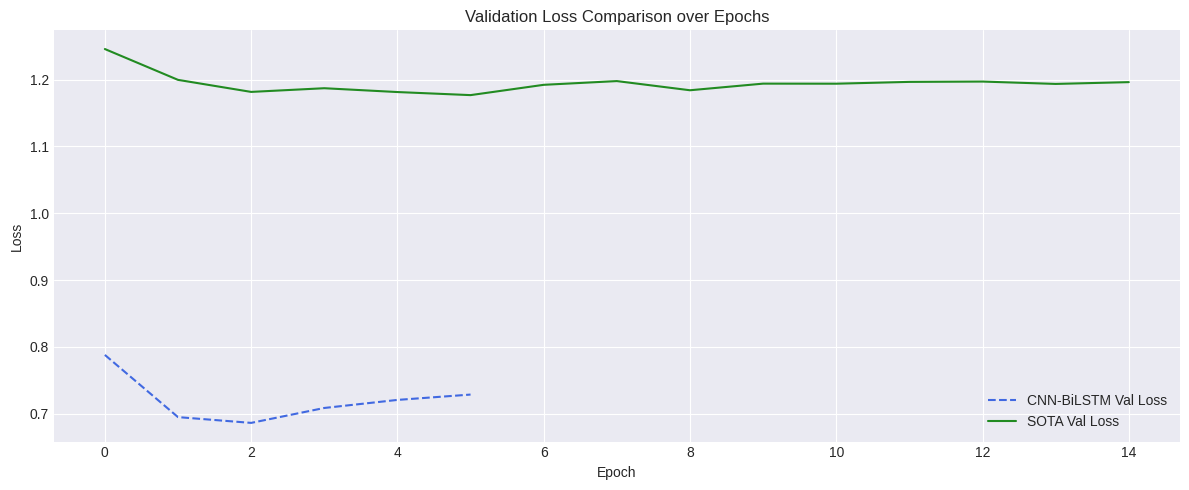

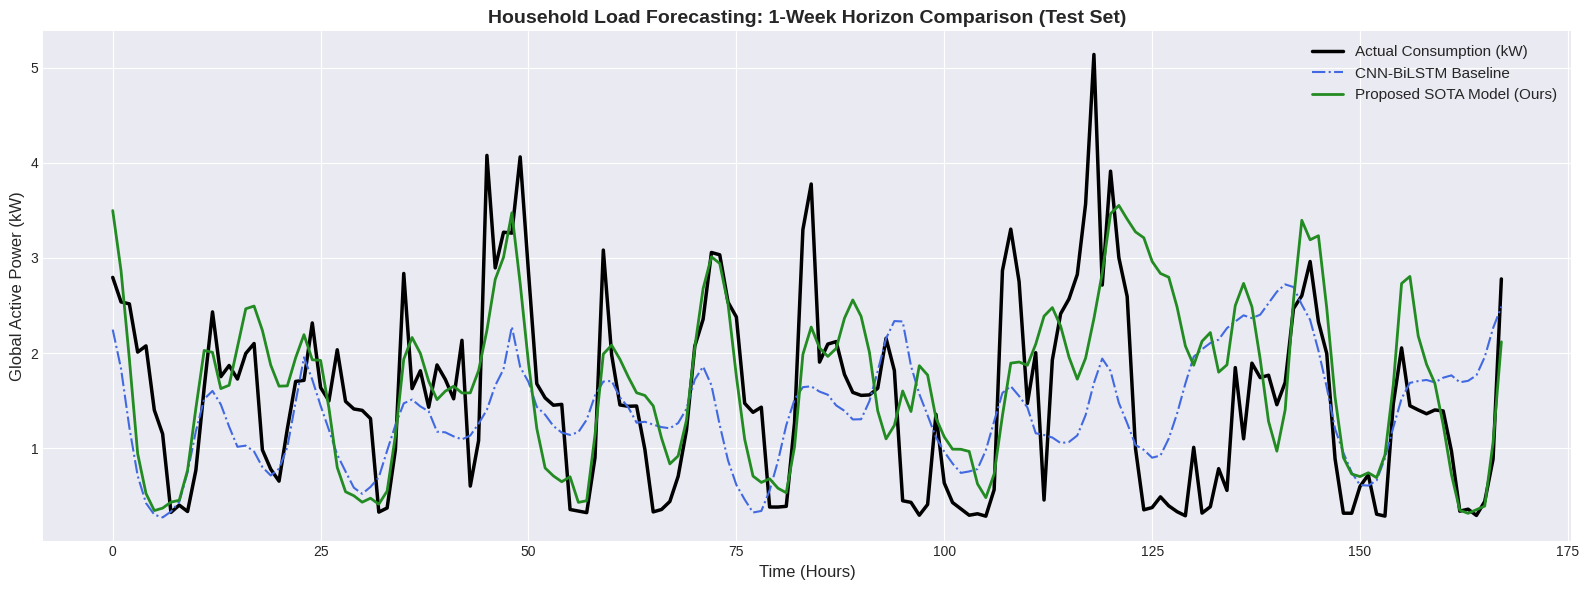

In [11]:
# 1. Plot Loss curves
plt.figure(figsize=(12, 5))
plt.plot(cnn_history['val_loss'], label='CNN-BiLSTM Val Loss', color='royalblue', linestyle='--')
plt.plot(sota_history['val_loss'], label='SOTA Val Loss', color='forestgreen')
plt.title('Validation Loss Comparison over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Reconstruct a continuous 1-week slice of forecast (168 hours)
plot_start = 500
plot_len = 168

actuals_plot = []
cnn_plot = []
sota_plot = []

for i in range(plot_start, plot_start + plot_len, 24):
    actuals_plot.extend(actuals[i, :])
    cnn_plot.extend(cnn_preds[i, :])
    sota_plot.extend(sota_preds[i, :])

plt.figure(figsize=(16, 6))
plt.plot(actuals_plot, label='Actual Consumption (kW)', color='black', linewidth=2.5)
plt.plot(cnn_plot, label='CNN-BiLSTM Baseline', color='royalblue', linestyle='-.', linewidth=1.5)
plt.plot(sota_plot, label='Proposed SOTA Model (Ours)', color='forestgreen', linestyle='-', linewidth=2)
plt.title('Household Load Forecasting: 1-Week Horizon Comparison (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Global Active Power (kW)', fontsize=12)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 11. Save Models for Application
We save the trained models' weights so they can be loaded by an application (e.g., a dashboard or API). We save:
1. The CNN-BiLSTM baseline model weights to `cnn_bilstm_baseline.pth`.
2. The SOTA model's averaged weights (extracted from the SWA wrapper) to `sota_model_weights.pth`.


In [12]:
# 1. Save CNN-BiLSTM baseline
torch.save(cnn_model.state_dict(), 'cnn_bilstm_baseline.pth')
print("Saved CNN-BiLSTM baseline weights to cnn_bilstm_baseline.pth")

# 2. Save SOTA Model (extracting the raw model state dict from the SWA AveragedModel wrapper)
if hasattr(sota_model, 'module'):
    sota_state_dict = sota_model.module.state_dict()
else:
    sota_state_dict = sota_model.state_dict()

torch.save(sota_state_dict, 'sota_model_weights.pth')
print("Saved SOTA model weights to sota_model_weights.pth")


Saved CNN-BiLSTM baseline weights to cnn_bilstm_baseline.pth
Saved SOTA model weights to sota_model_weights.pth
